Şu anki çalışma dizini: c:\Users\engin\fuel_intelligence
Klasördeki dosyalar: ['.git', '.gitignore', '.vscode', 'control.ipynb', 'control_integrated.csv', 'engine.csv', 'engine.ipynb', 'engine.py', 'mpc.py', 'terminal', '__pycache__']


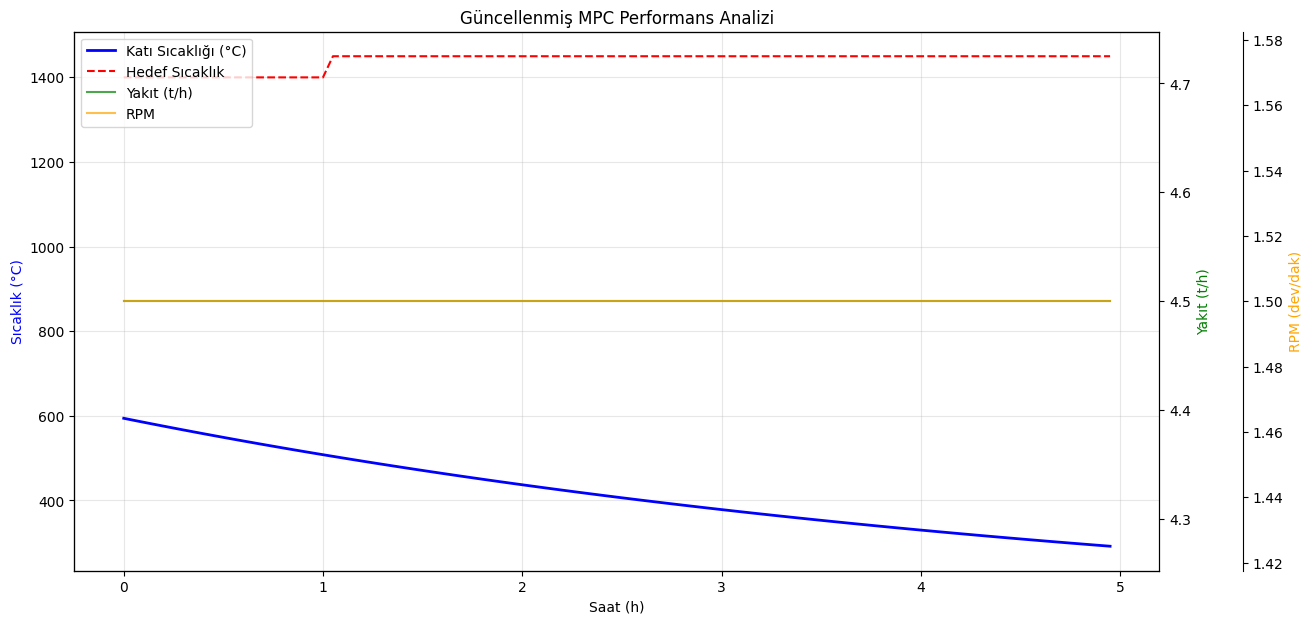

Ortalama Mutlak Hata (MAE): 1019.82 °C
Maksimum Hata: 1158.19 °C


In [1]:
# %% [markdown]
# # Fırın MPC Performans Analizi
# Bu analiz, MPC kontrolcüsünün set-point değişimine tepkisini ve fırın sıcaklık kararlılığını inceler.

# %%
import os
print("Şu anki çalışma dizini:", os.getcwd())
# Eğer 'control_integrated.csv' bu listede yoksa, yol hatası alırsın:
print("Klasördeki dosyalar:", os.listdir())


import pandas as pd
import matplotlib.pyplot as plt

# CSV verisini yükle
df = pd.read_csv('control_integrated.csv')

# Görselleştirme - Güncellenmiş
fig, ax1 = plt.subplots(figsize=(14, 7))

# 1. Sol eksen: Sıcaklık
ax1.plot(df['Time'], df['Ts_burning'], label='Katı Sıcaklığı (°C)', color='blue', linewidth=2)
ax1.plot(df['Time'], df['Target'], label='Hedef Sıcaklık', linestyle='--', color='red')
ax1.set_xlabel('Saat (h)')
ax1.set_ylabel('Sıcaklık (°C)', color='blue')
ax1.grid(True, alpha=0.3)

# 2. Sağ eksenler: Yakıt ve RPM için çift y-ekseni (Twinx)
ax2 = ax1.twinx()
ax3 = ax1.twinx()

# RPM'i sağa biraz kaydırıp ayrı bir eksen yapalım
ax3.spines['right'].set_position(('outward', 60)) # Sağ ekseni dışarı kaydır

# Grafikleri çiz
p1 = ax2.plot(df['Time'], df['Fuel'], label='Yakıt (t/h)', color='green', alpha=0.7)
p2 = ax3.plot(df['Time'], df['RPM'], label='RPM', color='orange', alpha=0.7)

# Eksen ayarları
ax2.set_ylabel('Yakıt (t/h)', color='green')
ax3.set_ylabel('RPM (dev/dak)', color='orange')

# Lejantları birleştir
lines = [ax1.get_lines()[0], ax1.get_lines()[1], p1[0], p2[0]]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title("Güncellenmiş MPC Performans Analizi")
plt.show()

# %% [markdown]
# ### Performans Metrikleri
# MPC'nin set-point'e ulaşma başarısını ölçüyoruz.
# %%
# Hata (Error) analizi
df['Error'] = abs(df['Ts_burning'] - df['Target'])
mean_error = df['Error'].mean()
max_error = df['Error'].max()

print(f"Ortalama Mutlak Hata (MAE): {mean_error:.2f} °C")
print(f"Maksimum Hata: {max_error:.2f} °C")

In [14]:
# CSV verisini yükle
df = pd.read_csv('control_integrated.csv')

# --- HATA AYIKLAMA: SÜTUN İSİMLERİNİ KONTROL ET ---
print(df.columns)

FileNotFoundError: [Errno 2] No such file or directory: 'control_integrated.csv'